# figures

Designed from scratch, reading only caches (the zarr product, the KS netCDFs, the Burke
impact file). One figure per act:

1. **The design** — three ways to occupy the same warming level: aerosol pathway,
   emissions scenario, direction of travel. Shows exactly which decades the test compares.
2. **The test** — why the asymptotic KS cannot be used on monthly climate data, and the
   block-permutation replacement with its measured false-positive floor.
3. **The result** — every comparison on one scale: the pathway doesn't matter at matched
   warming, except when the level is approached from above.
4. **The consequence** — what the aerosol pathway is worth in Burke (2015) GDP-growth
   units, and why internal variability swamps it.

Outputs: `figures/story_fig{1..4}_*.png`.

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cmocean

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/path_independence')
from funcs_support import get_params
import ks_tools as kt

dir_list = get_params()
warnings.filterwarnings('ignore', category=FutureWarning)

P       = dir_list['aux'] + 'gwl_timeseries.zarr'
SCEN_KS = dir_list['aux'] + 'diagnostics/ks_scenarios/'
GWL_KS  = dir_list['aux'] + 'diagnostics/ramip_gwl/'
ENSP    = dir_list['aux'] + 'diagnostics/ks_blockperm_enspairs/CanESM5-1.nc'
BURKE   = dir_list['aux'] + 'diagnostics/impacts/burke_gwl2.0.nc'
out_dir = dir_list['aux'] + '../figures/'

ALPHA, FLOOR, WIN, GWL = 0.05, 0.057, 10, 2.0

# Okabe-Ito, colorblind-safe, fixed assignment
C_ANCHOR, C_CLEAN = '#D55E00', '#0072B2'       # ssp370 / ssp370-126aer
C_SSP = {'ssp126': '#009E73', 'ssp245': '#E69F00', 'ssp585': '#CC3311'}
C_OVER, C_RISE = '#882255', '#44AA99'          # declining / rising

gmst = xr.open_zarr(P, group='gmst')
gwl  = xr.open_zarr(P, group='gwl')


def member_lines(ax, mod, exp, color, lw=0.7, alpha=0.6, label=None):
    s = gmst.gmst_anom.sel(model=mod, exp=exp).rolling(year=WIN).mean()
    ok = s.notnull().any('year')
    s = s.isel(member=np.where(ok)[0]).load()
    for i, m in enumerate(s.member.values):
        ax.plot(s.year, s.sel(member=m), color=color, lw=lw, alpha=alpha,
                label=label if i == 0 else None)
    return s


def shade_window(ax, end_year, color, alpha=0.25):
    if np.isfinite(end_year):
        ax.axvspan(end_year - WIN + 1, end_year, color=color, alpha=alpha, lw=0)

## Figure 1 — the design

Each panel is one comparison family, drawn from the zarr. Shaded bands are the actual 10-yr
windows the KS test compared (ensemble-mean crossing year). The point of the figure: in every
family both samples sit at **the same global warming**, and the only thing that changes is how
they got there.

scenario panel model: CESM2


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/story_fig1_design.png


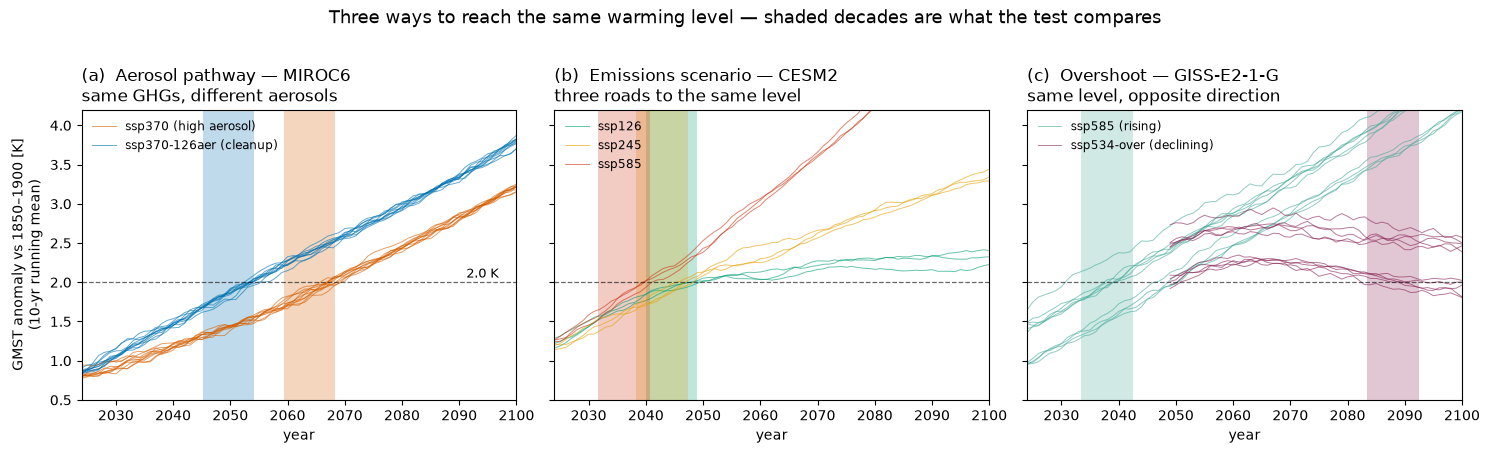

In [2]:
# pick the scenario-panel model: needs all three SSPs to reach the GWL
scen_mod = None
for m in [str(x) for x in gwl.model.values]:
    w = gwl.window_end.sel(model=m, gwl=GWL, exp=['ssp126', 'ssp245', 'ssp585'])
    if bool(w.notnull().any('member').all()):
        scen_mod = m
        break
print('scenario panel model:', scen_mod)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)

# (a) aerosol pathway — MIROC6, biggest lead
mod = 'MIROC6'
member_lines(axs[0], mod, 'ssp370', C_ANCHOR, label='ssp370 (high aerosol)')
member_lines(axs[0], mod, 'ssp370-126aer', C_CLEAN, label='ssp370-126aer (cleanup)')
for exp, c in [('ssp370', C_ANCHOR), ('ssp370-126aer', C_CLEAN)]:
    shade_window(axs[0], float(gwl.window_end.sel(model=mod, exp=exp, gwl=GWL).mean()), c)
axs[0].set_title(f'(a)  Aerosol pathway — {mod}\nsame GHGs, different aerosols', loc='left')
axs[0].set_ylabel('GMST anomaly vs 1850–1900 [K]\n(10-yr running mean)')

# (b) emissions scenario
for exp, c in C_SSP.items():
    member_lines(axs[1], scen_mod, exp, c, label=exp)
    shade_window(axs[1], float(gwl.window_end.sel(model=scen_mod, exp=exp, gwl=GWL).mean()), c)
axs[1].set_title(f'(b)  Emissions scenario — {scen_mod}\nthree roads to the same level', loc='left')

# (c) overshoot — GISS, level occupied twice
mod = 'GISS-E2-1-G'
member_lines(axs[2], mod, 'ssp585', C_RISE, label='ssp585 (rising)')
member_lines(axs[2], mod, 'ssp534-over', C_OVER, label='ssp534-over (declining)')
shade_window(axs[2], float(gwl.window_end.sel(model=mod, exp='ssp585', gwl=GWL).mean()), C_RISE)
shade_window(axs[2], float(gwl.down_end.sel(model=mod, exp='ssp534-over', gwl=GWL).mean()), C_OVER)
axs[2].set_title(f'(c)  Overshoot — {mod}\nsame level, opposite direction', loc='left')

for ax in axs:
    ax.axhline(GWL, color='k', ls='--', lw=0.9, alpha=0.6)
    ax.set_xlim(2024, 2100)
    ax.set_ylim(0.5, 4.2)
    ax.set_xlabel('year')
    ax.legend(loc='upper left', fontsize=8.5, frameon=False)
axs[0].text(2097, GWL + 0.06, f'{GWL} K', ha='right', fontsize=9)

fig.suptitle('Three ways to reach the same warming level — shaded decades are what the test compares',
             y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(out_dir + 'story_fig1_design.png', dpi=180, bbox_inches='tight')
print('saved', out_dir + 'story_fig1_design.png')

## Figure 2 — the test

- **(a)** measured false-positive rates from `method/ks_block_permutation.ipynb` (500
  trials/case): the asymptotic KS rejects 71% of the time under ENSO-like persistence and 0.5%
  on real same-forcing pairs — wrong in both directions. The block-permutation test sits at
  nominal size where it matters.
- **(b)** the calibration on the full grid: 45 CanESM5-1 same-forcing member pairs; per-pixel
  fraction rejecting is flat noise.
- **(c)** the land fraction of those 45 pairs — mean **0.057**, the floor every result is read
  against.

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


45 pairs, land-fraction mean 0.057


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/story_fig2_test.png


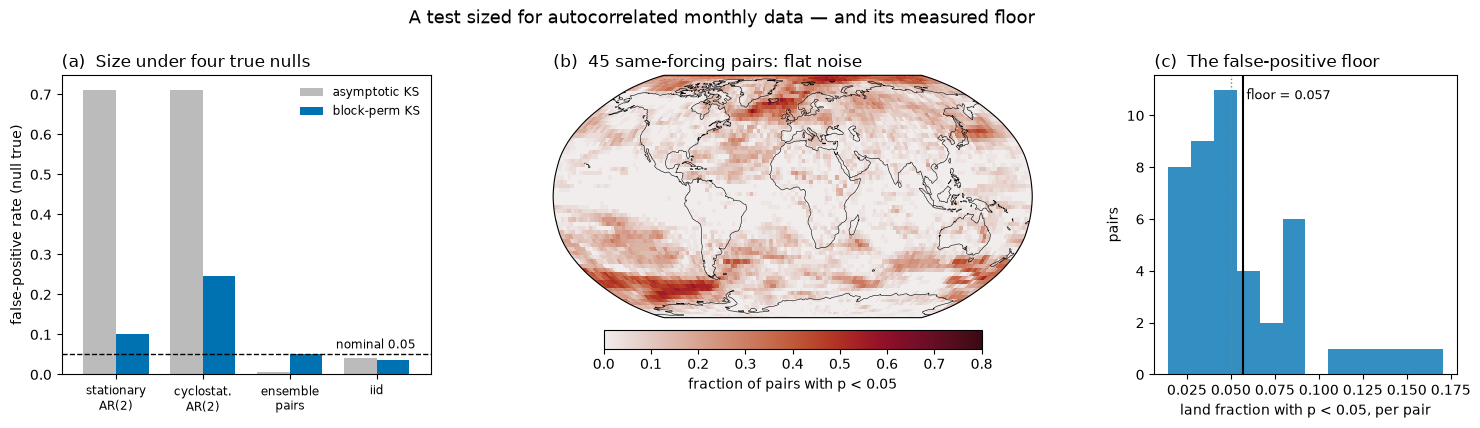

In [3]:
# (a) numbers measured in method/ks_block_permutation.ipynb (500 trials, 999 draws)
size = pd.DataFrame({
    'asymptotic KS': [0.710, 0.712, 0.005, 0.042],
    'block-perm KS': [0.100, 0.246, 0.051, 0.036],
}, index=['stationary\nAR(2)', 'cyclostat.\nAR(2)', 'ensemble\npairs', 'iid'])

# (b, c) the 45 same-forcing pairs
ens = xr.open_dataset(ENSP).load()
frac_ens = (ens.p_blockperm < ALPHA).mean('pair')
# floor convention from method/ks_blockperm_diagnostics.ipynb: land, no Antarctica
land = kt.land_mask(ens.lat.values, ens.lon.values) & (ens.lat.values > -60)[:, None]
p = ens.p_blockperm.transpose('pair', 'lat', 'lon').values
lf_pairs = ((p < ALPHA) & land).sum(axis=(1, 2)) / land.sum()
print(f'{len(lf_pairs)} pairs, land-fraction mean {lf_pairs.mean():.3f}')

fig = plt.figure(figsize=(15, 4.4))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.1, 1.5, 0.9], wspace=0.28,
                       left=0.06, right=0.99, top=0.82, bottom=0.14)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], projection=ccrs.Robinson())
ax3 = fig.add_subplot(gs[2])

size.plot.bar(ax=ax1, width=0.75, color=['#BBBBBB', '#0072B2'], legend=True)
ax1.axhline(ALPHA, color='k', ls='--', lw=1)
ax1.text(3.45, ALPHA + 0.015, 'nominal 0.05', ha='right', fontsize=8.5)
ax1.set_ylabel('false-positive rate (null true)')
ax1.legend(fontsize=8.5, frameon=False)
plt.setp(ax1.get_xticklabels(), rotation=0, fontsize=8.5)
ax1.set_title('(a)  Size under four true nulls', loc='left')

im = ax2.pcolormesh(frac_ens.lon, frac_ens.lat, frac_ens, cmap=cmocean.cm.amp,
                    vmin=0, vmax=0.8, transform=ccrs.PlateCarree())
ax2.coastlines(lw=0.4)
ax2.set_title('(b)  45 same-forcing pairs: flat noise', loc='left')
plt.colorbar(im, ax=ax2, orientation='horizontal', pad=0.04, shrink=0.75,
             label=f'fraction of pairs with p < {ALPHA}')

ax3.hist(lf_pairs, bins=12, color='#0072B2', alpha=0.8)
ax3.axvline(lf_pairs.mean(), color='k', lw=1.5)
ax3.text(lf_pairs.mean() + 0.002, ax3.get_ylim()[1] * 0.92,
         f'floor = {lf_pairs.mean():.3f}', fontsize=9)
ax3.axvline(ALPHA, color='0.5', ls=':', lw=1)
ax3.set_xlabel(f'land fraction with p < {ALPHA}, per pair')
ax3.set_ylabel('pairs')
ax3.set_title('(c)  The false-positive floor', loc='left')

fig.suptitle('A test sized for autocorrelated monthly data — and its measured floor',
             y=0.97, fontsize=13)
fig.savefig(out_dir + 'story_fig2_test.png', dpi=180, bbox_inches='tight')
print('saved', out_dir + 'story_fig2_test.png')

## Figure 3 — the result

- **(a)** every comparison as one dot: land fraction rejecting vs the floor, grouped into the
  three families. Aerosol and scenario sit on the floor; overshoot doesn't.
- **(b)** the aerosol comparison holds across all four variables — including `pr`, which
  Mithal et al. flag as the GWL failure mode across GCMs.
- **(c, d)** same model, same level, same n: aerosol pathway vs overshoot, per-pixel fraction
  of runs rejecting.

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/story_fig3_result.png


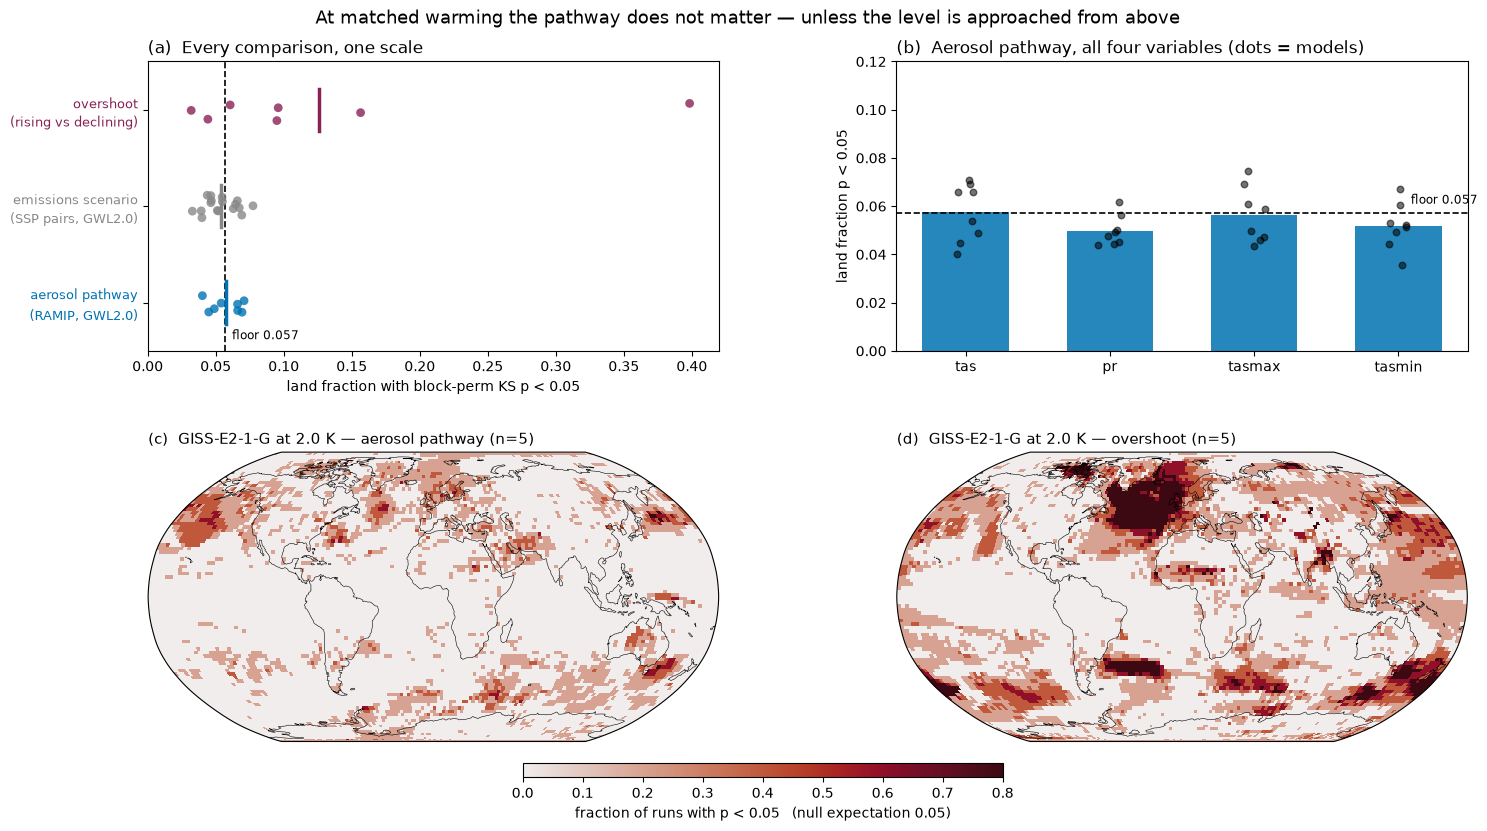

In [4]:
rows = []
for fn in sorted(glob.glob(f'{GWL_KS}ks/*.nc')):
    ds = xr.open_dataset(fn).load()
    rows.append({'family': 0, 'lf': kt.land_fraction(ds, 'run', ALPHA)})
for fn in sorted(glob.glob(f'{SCEN_KS}scen_*_tas.nc')):
    ds = xr.open_dataset(fn).load()
    rows.append({'family': 1, 'lf': kt.land_fraction(ds, 'pair', ALPHA)})
for fn in sorted(glob.glob(f'{SCEN_KS}over_*_tas.nc')):
    ds = xr.open_dataset(fn).load()
    rows.append({'family': 2, 'lf': kt.land_fraction(ds, 'pair', ALPHA)})
fam = pd.DataFrame(rows)
fam_names = ['aerosol pathway\n(RAMIP, GWL2.0)', 'emissions scenario\n(SSP pairs, GWL2.0)',
             'overshoot\n(rising vs declining)']
fam_cols = ['#0072B2', '#888888', '#882255']

# by-variable land fractions (RAMIP aerosol pair at GWL2.0)
var_lf = {}
for var, sub in [('tas', 'ks'), ('pr', 'ks_pr'), ('tasmax', 'ks_tasmax'), ('tasmin', 'ks_tasmin')]:
    fns = sorted(glob.glob(f'{GWL_KS}{sub}/*.nc'))
    var_lf[var] = [kt.land_fraction(xr.open_dataset(f).load(), 'run', ALPHA) for f in fns]

ram = xr.open_dataset(f'{SCEN_KS}ramip_gwl2.0_GISS-E2-1-G_tas.nc').load()
ove = xr.open_dataset(f'{SCEN_KS}over_gwl2.0_GISS-E2-1-G_tas.nc').load()
frac_ram = (ram.p_blockperm < ALPHA).mean('pair')
frac_ove = (ove.p_blockperm < ALPHA).mean('pair')

fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 4, height_ratios=[1, 1], hspace=0.35, wspace=0.9,
                       left=0.1, right=0.98, top=0.90, bottom=0.05)
ax_a = fig.add_subplot(gs[0, :2])
ax_b = fig.add_subplot(gs[0, 2:])
ax_c = fig.add_subplot(gs[1, :2], projection=ccrs.Robinson())
ax_d = fig.add_subplot(gs[1, 2:], projection=ccrs.Robinson())

rng = np.random.default_rng(3)
for i in range(3):
    v = fam[fam.family == i].lf.values
    ax_a.scatter(v, i + rng.uniform(-0.12, 0.12, len(v)), s=40, color=fam_cols[i],
                 alpha=0.8, edgecolor='none', zorder=3)
    ax_a.plot([v.mean()] * 2, [i - 0.22, i + 0.22], color=fam_cols[i], lw=2.5, zorder=4)
ax_a.axvline(FLOOR, color='k', ls='--', lw=1.2)
ax_a.text(FLOOR + 0.005, -0.38, f'floor {FLOOR}', fontsize=8.5)
ax_a.set_yticks(range(3))
ax_a.set_yticklabels(fam_names, fontsize=9.5, linespacing=1.5)
for lab, c in zip(ax_a.get_yticklabels(), fam_cols):
    lab.set_color(c)
ax_a.set_xlim(0, 0.42)
ax_a.set_ylim(-0.5, 2.5)
ax_a.set_xlabel(f'land fraction with block-perm KS p < {ALPHA}')
ax_a.set_title('(a)  Every comparison, one scale', loc='left')

pos = np.arange(len(var_lf))
means = [np.mean(v) for v in var_lf.values()]
ax_b.bar(pos, means, width=0.6, color='#0072B2', alpha=0.85)
for i, v in enumerate(var_lf.values()):
    ax_b.scatter(np.full(len(v), i) + rng.uniform(-0.1, 0.1, len(v)), v, s=22,
                 color='k', alpha=0.55, zorder=3)
ax_b.axhline(FLOOR, color='k', ls='--', lw=1.2)
ax_b.text(len(var_lf) - 0.45, FLOOR + 0.004, f'floor {FLOOR}', ha='right', fontsize=8.5)
ax_b.set_xticks(pos)
ax_b.set_xticklabels(var_lf.keys())
ax_b.set_ylabel(f'land fraction p < {ALPHA}')
ax_b.set_ylim(0, 0.12)
ax_b.set_title('(b)  Aerosol pathway, all four variables (dots = models)', loc='left')

for ax, f, ttl in [(ax_c, frac_ram, f'(c)  GISS-E2-1-G at {GWL} K — aerosol pathway (n=5)'),
                   (ax_d, frac_ove, f'(d)  GISS-E2-1-G at {GWL} K — overshoot (n=5)')]:
    im = ax.pcolormesh(f.lon, f.lat, f, cmap=cmocean.cm.amp, vmin=0, vmax=0.8,
                       transform=ccrs.PlateCarree())
    ax.coastlines(lw=0.4)
    ax.set_title(ttl, loc='left', fontsize=10.5)
cax = fig.add_axes([0.35, 0.005, 0.32, 0.018])
plt.colorbar(im, cax=cax, orientation='horizontal',
             label=f'fraction of runs with p < {ALPHA}   (null expectation {ALPHA})')

fig.suptitle('At matched warming the pathway does not matter — unless the level is approached from above',
             fontsize=13, y=0.965)
fig.savefig(out_dir + 'story_fig3_result.png', dpi=180, bbox_inches='tight')
print('saved', out_dir + 'story_fig3_result.png')

## Figure 4 — the consequence

Burke, Hsiang & Miguel (2015) growth response applied to both RAMIP arms at their own GWL2.0
decades, difference `126aer − ssp370`. The pathway signal has a coherent sign pattern (South
Asia loses, high latitudes gain) but is smaller than a decade of internal variability almost
everywhere — the impact-level restatement of the statistical result.

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


pathway\nsignal          0.00101
model\nspread            0.00162
internal\nvariability    0.00337
dtype: float64


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/story_fig4_impacts.png


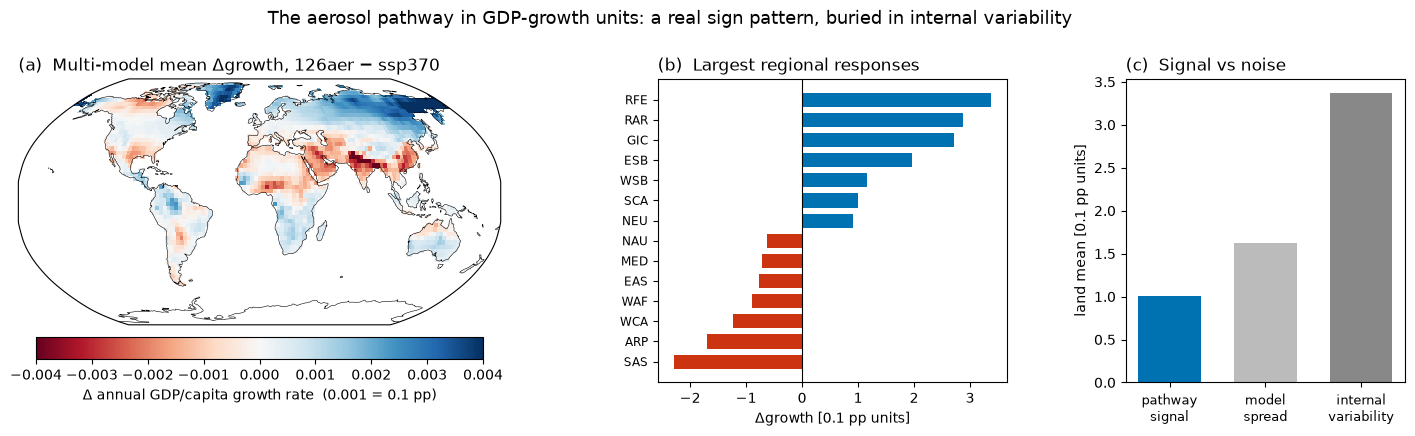

In [5]:
imp = xr.open_dataset(BURKE).load()
dg = imp.dg                                       # (model, run, lat, lon)
sig = dg.mean(['model', 'run'])                   # the pathway signal
internal = dg.std('run').mean('model')            # internal spread
model_sp = dg.mean('run').std('model')            # model spread

# Burke response is meaningless on ice sheets; same no-Antarctica convention as the floor
land = kt.land_mask(dg.lat.values, dg.lon.values) & (dg.lat.values > -60)[:, None]
wt = np.cos(np.deg2rad(dg.lat)).broadcast_like(sig).where(land)

import regionmask
ar6 = regionmask.defined_regions.ar6.land
rmask = ar6.mask(sig.lon, sig.lat)
reg_rows = []
for i, ab in zip(ar6.numbers, ar6.abbrevs):
    m = (rmask == i) & land
    if m.sum() < 4:
        continue
    w = wt.where(m)
    reg_rows.append({'region': ab, 'dg': float(sig.where(m).weighted(w.fillna(0)).mean())})
reg = pd.DataFrame(reg_rows).set_index('region').dg.sort_values()
show = pd.concat([reg.head(7), reg.tail(7)])

lm = lambda a: float(a.where(land).weighted(wt.fillna(0)).mean())
spread = pd.Series({'pathway\nsignal': lm(abs(sig)),
                    'model\nspread': lm(model_sp),
                    'internal\nvariability': lm(internal)})
print(spread.round(5))

fig = plt.figure(figsize=(15, 4.6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.6, 1.0, 0.8], wspace=0.3,
                       left=0.04, right=0.99, top=0.82, bottom=0.16)
ax1 = fig.add_subplot(gs[0], projection=ccrs.Robinson())
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

vmax = 0.004
im = ax1.pcolormesh(sig.lon, sig.lat, sig.where(land), cmap='RdBu', vmin=-vmax, vmax=vmax,
                    transform=ccrs.PlateCarree())
ax1.coastlines(lw=0.4)
ax1.set_title('(a)  Multi-model mean Δgrowth, 126aer − ssp370', loc='left')
plt.colorbar(im, ax=ax1, orientation='horizontal', pad=0.04, shrink=0.8,
             label='Δ annual GDP/capita growth rate  (0.001 = 0.1 pp)')

cols = ['#CC3311' if v < 0 else '#0072B2' for v in show.values]
ax2.barh(range(len(show)), show.values * 1000, color=cols, height=0.7)
ax2.set_yticks(range(len(show)))
ax2.set_yticklabels(show.index, fontsize=8.5)
ax2.axvline(0, color='k', lw=0.8)
ax2.set_xlabel('Δgrowth [0.1 pp units]')
ax2.set_title('(b)  Largest regional responses', loc='left')

ax3.bar(range(3), spread.values * 1000, color=['#0072B2', '#BBBBBB', '#888888'], width=0.65)
ax3.set_xticks(range(3))
ax3.set_xticklabels(spread.index, fontsize=9)
ax3.set_ylabel('land mean [0.1 pp units]')
ax3.set_title('(c)  Signal vs noise', loc='left')

fig.suptitle('The aerosol pathway in GDP-growth units: a real sign pattern, buried in internal variability',
             y=0.97, fontsize=13)
fig.savefig(out_dir + 'story_fig4_impacts.png', dpi=180, bbox_inches='tight')
print('saved', out_dir + 'story_fig4_impacts.png')